In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("sales_data.csv")


In [4]:
df.head()


,Date,Region,Product,Category,Quantity,Price,Cost
0,2024-01-05,North,Laptop,Electronics,2,60000,50000
1,2024-01-08,South,Mobile,Electronics,5,20000,15000
2,2024-01-15,East,Tablet,Electronics,3,30000,22000
3,2024-02-02,West,Laptop,Electronics,1,60000,50000
4,2024-02-10,North,Mobile,Electronics,4,20000,15000


In [5]:
df['Date'] = pd.to_datetime(df['Date'])


In [6]:
df.isnull().sum()


Date        0
Region      0
Product     0
Category    0
Quantity    0
Price       0
Cost        0
dtype: int64

In [27]:
df['Revenue'] = df['Quantity'] * df['Price']
df['Profit'] = df['Quantity'] * (df['Price'] - df['Cost'])



In [26]:
df['Month'] = df['Date'].dt.month_name()
df.head(9)

,Date,Region,Product,Category,Quantity,Price,Cost,Revenue,Profit,Month
0,2024-01-05,North,Laptop,Electronics,2,60000,50000,120000,20000,January
1,2024-01-08,South,Mobile,Electronics,5,20000,15000,100000,25000,January
2,2024-01-15,East,Tablet,Electronics,3,30000,22000,90000,24000,January
3,2024-02-02,West,Laptop,Electronics,1,60000,50000,60000,10000,February
4,2024-02-10,North,Mobile,Electronics,4,20000,15000,80000,20000,February
5,2024-02-18,South,Tablet,Electronics,2,30000,22000,60000,16000,February
6,2024-03-05,East,Laptop,Electronics,3,60000,50000,180000,30000,March
7,2024-03-12,West,Mobile,Electronics,6,20000,15000,120000,30000,March
8,2024-03-20,North,Tablet,Electronics,2,30000,22000,60000,16000,March


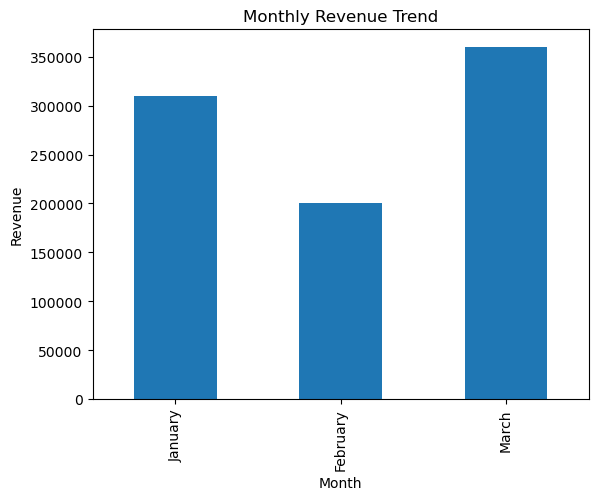

In [29]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
monthly_sales = df.groupby('Month',observed=True)['Revenue'].sum()

monthly_sales.plot(kind='bar')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


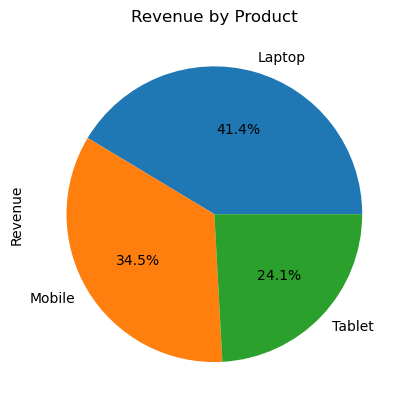

In [10]:
product_sales = df.groupby('Product')['Revenue'].sum()

product_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Product")
plt.show()


In [11]:
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
average_order_value = np.mean(df['Revenue'])

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Average Order Value:", average_order_value)


Total Revenue: 870000
Total Profit: 191000
Average Order Value: 96666.66666666667


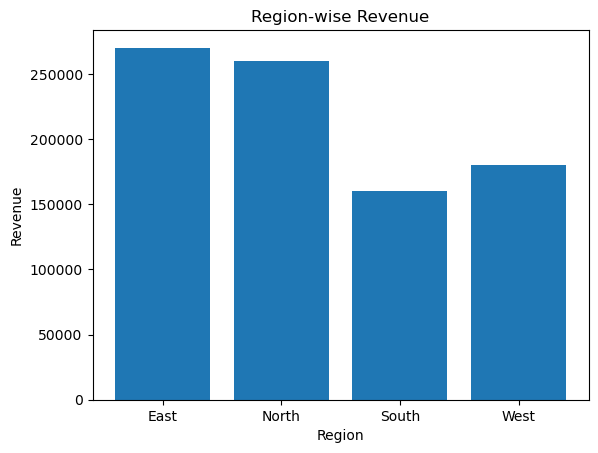

In [12]:
region_revenue = df.groupby('Region')['Revenue'].sum()

plt.figure()
plt.bar(region_revenue.index, region_revenue.values)
plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()


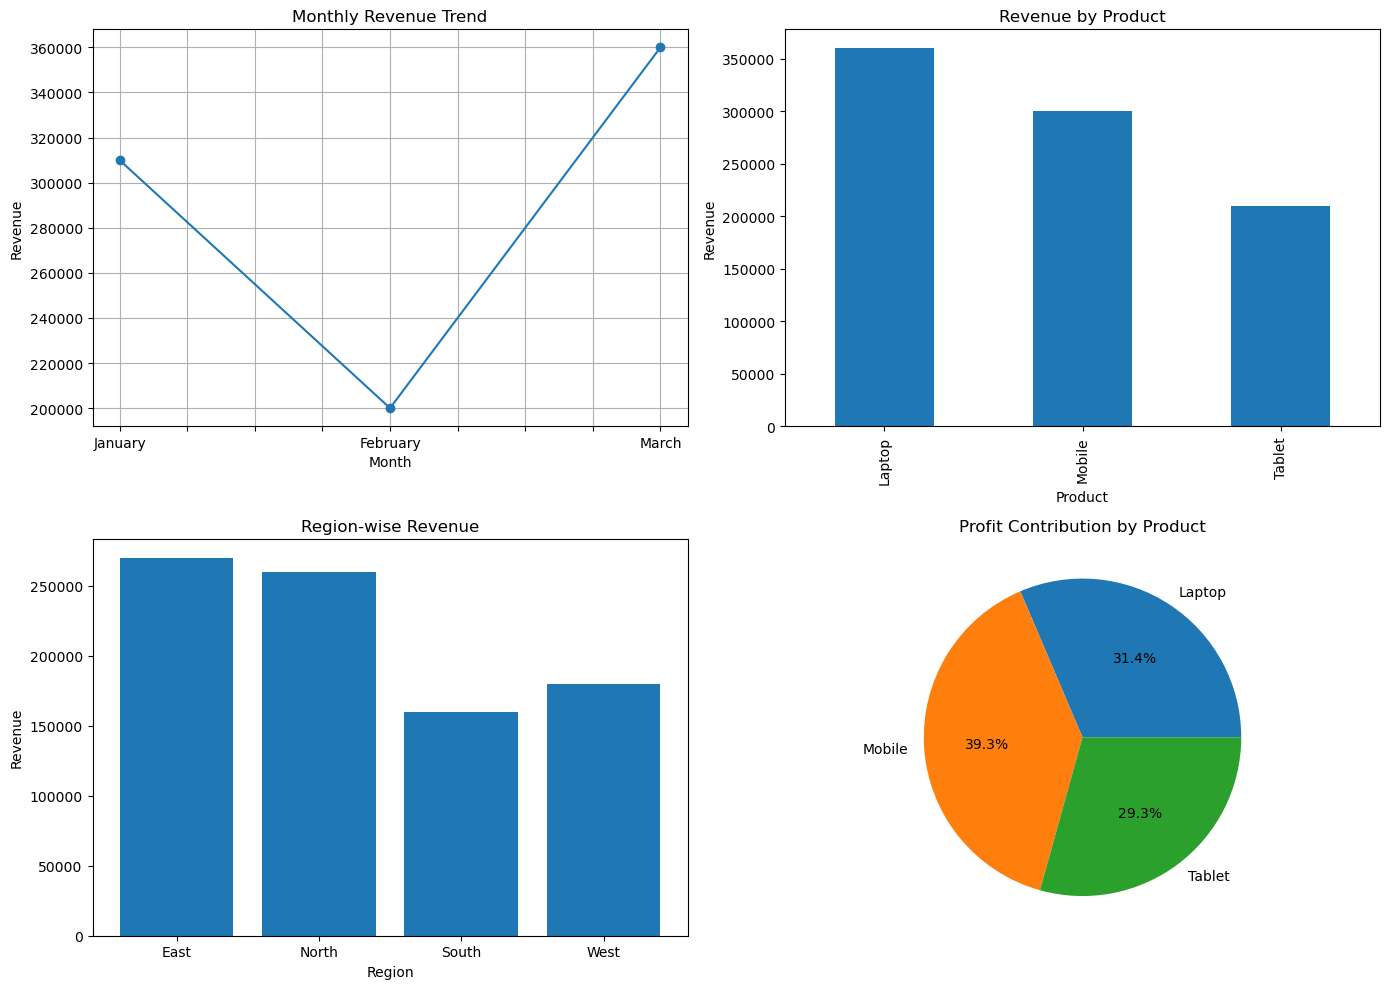

In [31]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_revenue = df.groupby('Month',observed=True)['Revenue'].sum()
product_revenue = df.groupby('Product')['Revenue'].sum()
region_revenue = df.groupby('Region')['Revenue'].sum()
product_profit = df.groupby('Product')['Profit'].sum()

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
monthly_revenue.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.subplot(2, 2, 2)
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.subplot(2, 2, 3)
plt.bar(region_revenue.index, region_revenue.values)
plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.subplot(2, 2, 4)
plt.pie(product_profit, labels=product_profit.index, autopct='%1.1f%%')
plt.title("Profit Contribution by Product")

plt.tight_layout()
plt.show()

